In [1]:
# Colab-Setup — lokal wird diese Zelle übersprungen.
import sys

if 'google.colab' in sys.modules:
    import os

    REPO_DIR = '/content/Wassermengenwirtschaft_und_Klimawandel'
    NB_DIR   = REPO_DIR + '/Inhalt/Notebooks/Hausarbeit'

    if not os.path.isdir(REPO_DIR):
        print('Colab-Setup: Repository wird geklont ...')
        get_ipython().system('git clone https://github.com/gjohnen1/Wassermengenwirtschaft_und_Klimawandel.git ' + REPO_DIR)
    get_ipython().run_line_magic('cd', NB_DIR)

    # requirements.txt installieren. pysheds benötigt numpy<2 → numpy wird
    # downgegradet, Colab-Paket-Resolver meldet ~10 Konflikte (jax, opencv,
    # pytensor, ...). Diese Warnungen sind kosmetisch — keine dieser Pakete
    # wird von der Hausarbeit verwendet.
    # only-if-needed minimiert das Mitreißen anderer Downgrades.
    print('Colab-Setup: Installiere Abhängigkeiten aus requirements.txt ...')
    get_ipython().run_line_magic(
        'pip',
        'install -q --upgrade-strategy only-if-needed -r '
        + REPO_DIR + '/requirements.txt'
    )
    print()
    print('Colab-Setup fertig.')
    print('Die pip-Resolver-Warnungen zu numpy>=2 (jax, opencv, pytensor, music21, ...)')
    print('sind kosmetisch — diese Pakete werden in der Hausarbeit nicht benutzt.')
    print('Falls im Folgenden ein "numpy.rec"- oder ABI-Fehler auftritt:')
    print('  Runtime > Restart runtime > diese Zelle erneut ausführen.')
else:
    print('Nicht in Colab erkannt — lokaler/Binder-Modus wird genutzt.')


Nicht in Colab erkannt — lokaler/Binder-Modus wird genutzt.


In [2]:
# Alle benötigten Pakete importieren
import os
import sys
import math
import pandas as pd
import numpy as np

# Plotting und Visualisierung
import matplotlib.pyplot as plt
import matplotlib.patches as mp
import matplotlib.colors as colors
import matplotlib.cm as cmx

# Bokeh für interaktive Plots
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
from bokeh.models import ColumnDataSource
from bokeh.layouts import gridplot

# Räumliche Datenverarbeitung
from pysheds.grid import Grid

In [3]:
# Aktuellen Arbeitsordner anzeigen (relevant beim ersten Lauf in Colab)
working_directory = os.getcwd()
print(working_directory)

C:\Users\grego\OneDrive - Universitaet Duisburg-Essen\GitHub\repos\Wassermengenwirtschaft_und_Klimawandel\Inhalt\Notebooks\Hausarbeit


In [4]:
# Importiere tägliche Niederschlagsdaten der DWD-Station 1303 (Essen-Bredeney)
data_path = '../../Notebook_Daten/Hausarbeit_Daten/'

daily_df = pd.read_csv(
    data_path + 'daily_1303.csv',
    sep=';', decimal=',', parse_dates=['date'], index_col='date',
)
# Falls Zeitstempel in UTC vorliegen: tz entfernen für saubere Slicing-Operationen
if daily_df.index.tz is not None:
    daily_df.index = daily_df.index.tz_localize(None)
daily_df.head()

,station_id,dataset,parameter,value,quality
date,,,,,
2024-01-02,1303,climate_summary,precipitation_height,21.4,1.0
2024-01-03,1303,climate_summary,precipitation_height,34.8,1.0
2024-01-04,1303,climate_summary,precipitation_height,6.3,1.0
2024-01-05,1303,climate_summary,precipitation_height,1.8,1.0
2024-01-06,1303,climate_summary,precipitation_height,0.3,1.0


In [5]:
# Importiere stündliche Niederschlagsdaten derselben Station
hourly_df = pd.read_csv(
    data_path + 'hourly_1303.csv',
    sep=';', decimal=',', parse_dates=['date'], index_col='date',
)
if hourly_df.index.tz is not None:
    hourly_df.index = hourly_df.index.tz_localize(None)
hourly_df.head()

,station_id,dataset,parameter,value,quality
date,,,,,
2024-01-01 12:00:00,1303,precipitation,precipitation_height,0.1,1.0
2024-01-01 13:00:00,1303,precipitation,precipitation_height,0.0,1.0
2024-01-01 14:00:00,1303,precipitation,precipitation_height,0.0,1.0
2024-01-01 15:00:00,1303,precipitation,precipitation_height,0.0,1.0
2024-01-01 16:00:00,1303,precipitation,precipitation_height,0.0,1.0


In [6]:
# Bokeh in Notebook ausgeben
from bokeh.resources import CDN
output_notebook(resources=CDN)

daily_source = ColumnDataSource(daily_df)
hourly_source = ColumnDataSource(hourly_df)

p = figure(title='Niederschlagsdaten Essen-Bredeney (DWD 1303)',
           width=750, height=300, x_axis_type='datetime')

p.vbar(x='date', width=pd.Timedelta(days=1), top='value',
       bottom=0, source=daily_source,
       legend_label='Tägl. Niederschlag', color='royalblue')

p.vbar(x='date', width=pd.Timedelta(hours=1), top='value',
       bottom=0, source=hourly_source,
       legend_label='Stündlicher Niederschlag', color='red')

p.legend.location = 'top_left'
p.xaxis.axis_label = 'Datum'
p.yaxis.axis_label = 'Niederschlag [mm]'
p.toolbar_location = 'above'
show(p)

Loading BokehJS ...

In [7]:
# Vergleich von tagesaggregierten stündlichen Daten mit den Tagessummen
hourly_check = hourly_df.loc['2024-02-03':'2024-02-04', 'value'].sum()
daily_check  = daily_df.loc['2024-02-03':'2024-02-04', 'value'].sum()
print(f'Summe stündlich  03.-04.02.2024 = {hourly_check:.1f} mm')
print(f'Summe täglich    03.-04.02.2024 = {daily_check:.1f} mm')
print('Diskrepanz:', round(hourly_check - daily_check, 2), 'mm')

Summe stündlich  03.-04.02.2024 = 21.0 mm
Summe täglich    03.-04.02.2024 = 20.0 mm
Diskrepanz: 1.0 mm


In [8]:
# Welche Spalten enthält der DWD-Datensatz?
print('daily_df Spalten:', list(daily_df.columns))
print('hourly_df Spalten:', list(hourly_df.columns))

daily_df Spalten: ['station_id', 'dataset', 'parameter', 'value', 'quality']
hourly_df Spalten: ['station_id', 'dataset', 'parameter', 'value', 'quality']


In [9]:
b, h = 2, 0.5  # Breite und Tiefe in Metern
# Querschnittsfläche
A = b * h
# Benetzter Umfang (offenes Rechteckprofil: Sohle + 2 Seitenwände)
perim = b + 2 * h
# hydraulischer Radius
R = A / perim
# Sohlgefälle
S = 0.005
# Manning-Rauhigkeitsbeiwert n (nicht Strickler k_st)
n_manning = 0.017

# durchschnittliche Fließgeschwindigkeit (Manning)
V_avg_Gerinne = (1.0 / n_manning) * R ** (2.0 / 3) * S ** 0.5
print(f'Die durchschnittliche Fließgeschwindigkeit bei vollem Durchfluss beträgt {V_avg_Gerinne:.2f} m/s')

# maximale Abflusskapazität
Q_Gerinne_Kapazitaet = V_avg_Gerinne * A
print(f'Die volle Abflusskapazität des Gerinnes beträgt {Q_Gerinne_Kapazitaet:.2f} m³/s')

Die durchschnittliche Fließgeschwindigkeit bei vollem Durchfluss beträgt 2.00 m/s
Die volle Abflusskapazität des Gerinnes beträgt 2.00 m³/s


In [10]:
def Zeitbeiwert_Spitzenabfluss(C, I, A_ha):
    """Berechne den Spitzenabfluss über das Zeitbeiwertverfahren (KOSTRA / SI).

    Args:
        C    : Abflussbeiwert [-]
        I    : Regenspende [l/(s·ha)]
        A_ha : Einzugsgebietsfläche [ha]

    Returns:
        Q : Scheitelabfluss [m³/s]
    """
    return C * I * A_ha * 1e-3

In [11]:
# KOSTRA-DWD-2020 Werte für Rasterzelle 131101 (Essen) — l/(s·ha)
# Werte aus OpenKO abgelesen für Wiederkehrintervalle T_n = 2 a und T_n = 100 a
# Schlüssel: Dauerstufe in Minuten -> (I_2a, I_100a)
IDF_dict = {
    5:    (280.0, 613.3),   # 5 min
    15:   (133.3, 293.3),   # 15 min
    60:   ( 49.4, 108.3),   # 60 min (1 h)
    1440: (  4.7,  10.3),   # 1440 min (24 h)
}

In [12]:
# Einzugsgebietsfläche: 1 km² = 100 ha
A_ha = 100

# Drei Werte für den Abflussbeiwert C: Minimum, mittlerer Wert, Maximum
C_values = [0.5, 0.7, 0.9]

figs = []
plot_colors = ['green', 'orange', 'red']
for k, (i_min, i_max) in IDF_dict.items():
    p = figure(title=f'Dauerstufe = {k} min', width=600, height=400)
    for idx, c in enumerate(C_values):
        Q_min = Zeitbeiwert_Spitzenabfluss(c, i_min, A_ha)
        Q_max = Zeitbeiwert_Spitzenabfluss(c, i_max, A_ha)
        print(f'{k} min, C={c}: Abflussbereich = {Q_min:.1f} – {Q_max:.1f} m³/s')
        x = [2, 100]              # Wiederkehrintervalle (Jahre)
        y = [Q_min, Q_max]
        p.line(x, y, legend_label=f'C={c}', color=plot_colors[idx], line_width=2)
        p.scatter(x, y, color=plot_colors[idx], size=8)
    p.yaxis.axis_label = 'Spitzenabfluss [m³/s]'
    p.xaxis.axis_label = 'Wiederkehrintervall [Jahre]'
    p.legend.location = 'top_left'
    figs.append(p)

5 min, C=0.5: Abflussbereich = 14.0 – 30.7 m³/s
5 min, C=0.7: Abflussbereich = 19.6 – 42.9 m³/s
5 min, C=0.9: Abflussbereich = 25.2 – 55.2 m³/s
15 min, C=0.5: Abflussbereich = 6.7 – 14.7 m³/s
15 min, C=0.7: Abflussbereich = 9.3 – 20.5 m³/s
15 min, C=0.9: Abflussbereich = 12.0 – 26.4 m³/s
60 min, C=0.5: Abflussbereich = 2.5 – 5.4 m³/s
60 min, C=0.7: Abflussbereich = 3.5 – 7.6 m³/s
60 min, C=0.9: Abflussbereich = 4.4 – 9.7 m³/s
1440 min, C=0.5: Abflussbereich = 0.2 – 0.5 m³/s
1440 min, C=0.7: Abflussbereich = 0.3 – 0.7 m³/s
1440 min, C=0.9: Abflussbereich = 0.4 – 0.9 m³/s


In [13]:
layout = gridplot(figs, ncols=2, width=350, height=300)
show(layout)

In [14]:
def calculate_N_eff(n_mm, cn):
    """Berechnet den abflusswirksamen Niederschlag N_eff [mm] aus N [mm] und CN.

    Args:
        n_mm : Niederschlagsmenge [mm]
        cn   : Curve Number [-]
    Returns:
        N_eff [mm]
    """
    a_a = 0.2  # Anfangsverlust-Anteil
    S = 254.0 * (100.0 / cn - 1.0)
    if n_mm > a_a * S:
        return (n_mm - a_a * S) ** 2 / (n_mm + (1 - a_a) * S)
    return 0.0

In [15]:
# KOSTRA-DWD-2020 Niederschlagshöhen [mm] für Rasterzelle 131101 (Essen)
# Schlüssel: Wiederkehrintervall (Jahre) -> Dict aus Dauerstufe (min) -> Niederschlag [mm]
IDF_dict_mm = {
    2: {            # 2-jährliches Ereignis
        5:     8.4,
        15:   12.0,
        60:   17.8,
        1440: 40.6,
    },
    100: {          # 100-jährliches Ereignis
        5:    18.4,
        15:   26.4,
        60:   39.0,
        1440: 89.3,
    },
}

# CN-Werte für Schotterplatz auf Bodengruppen A, B, C, D
CNs = [76, 85, 89, 91]

# Berechne effektiven Niederschlag für jede Kombination
CN_N_eff = {}
for return_period, durations in IDF_dict_mm.items():
    for duration, N in durations.items():
        CN_N_eff[(return_period, duration)] = [calculate_N_eff(N, cn) for cn in CNs]

cn_df = pd.DataFrame(CN_N_eff)
cn_df.index = CNs
cn_df.head()

2                                        100                       \
        5         15        60         1440      5         15         60     
76  0.000000  0.000000  0.037700   5.756412  0.067334  1.184585   5.108782   
85  0.000000  0.192504  1.454792  13.089292  1.640743  4.882673  12.050936   
89  0.134273  0.881966  3.093154  17.925314  3.376500  7.859298  16.699574   
91  0.399913  1.516110  4.307015  20.851862  4.647480  9.827059  19.533351   

               
         1440  
76  34.969534  
85  51.564559  
89  60.241821  
91  64.923479

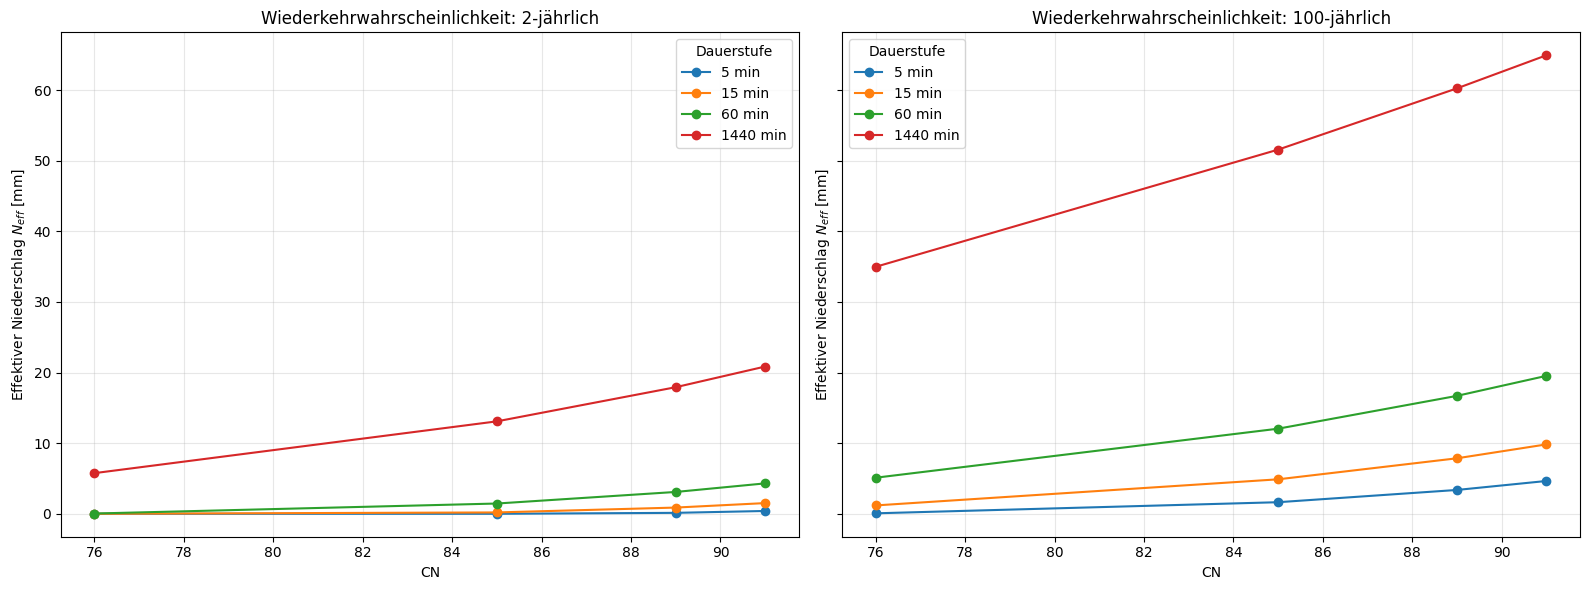

In [16]:
# Plot: Effektiver Niederschlag pro CN-Wert je Wiederkehrintervall und Dauerstufe
fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for i, (return_period, _) in enumerate(IDF_dict_mm.items()):
    ax = axs[i]
    for duration in IDF_dict_mm[return_period].keys():
        values = cn_df[(return_period, duration)]
        ax.plot(CNs, values, marker='o', label=f'{duration} min')
    ax.set_title(f'Wiederkehrwahrscheinlichkeit: {return_period}-jährlich')
    ax.set_xlabel('CN')
    ax.set_ylabel('Effektiver Niederschlag $N_{eff}$ [mm]')
    ax.legend(title='Dauerstufe')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
def berechne_t_sheet(n, L_m, P_mm, s):
    """NRCS-Sheet-Flow-Formel (Stunden).

    n    : Manning's effektiver Rauhigkeitskoeffizient [-]
    L_m  : Fließlänge [m]   (intern -> Fuß)
    P_mm : Niederschlagshöhe 2a/24h [mm]   (intern -> Zoll)
    s    : Gefälle [m/m]
    """
    L_ft = L_m * 3.28084
    P_in = P_mm / 25.4
    return 0.007 * (n * L_ft) ** 0.8 / (P_in ** 0.5 * s ** 0.4)


def berechne_t_shallow(L_m, befestigt, S):
    """NRCS-Shallow-Concentrated-Flow Formel (Stunden).

    L_m       : Länge [m]
    befestigt : True = bepflastert/asphaltiert, False = unbepflastert
    S         : Gefälle [m/m]
    """
    L_ft = L_m * 3.28084
    v_fps = (20.3282 if befestigt else 16.1345) * math.sqrt(S)  # Fuß/s
    return L_ft / (v_fps * 3600)


def berechne_t_channel(L_m, v_mps):
    """Gerinnefließzeit (Stunden)."""
    return L_m / (v_mps * 3600)

In [18]:
# Annahmen für unser kleines (1 km²) Einzugsgebiet:
# Sheet flow:
n_sheet = 0.15      # Grasbewuchs (typisch: Beton≈0.011, Gras≈0.15, Wald≈0.4)
L_sheet = 100        # m   (max. ca. 100 m bis Konzentration)
slope   = 0.005     # m/m
P_2a_24h_mm = 40.6  # KOSTRA 24h-Niederschlag, 2-jährlich

t_sheet   = berechne_t_sheet(n_sheet, L_sheet, P_2a_24h_mm, slope)

# Shallow concentrated flow:
L_shallow = 250
t_shallow = berechne_t_shallow(L_shallow, befestigt=True, S=slope)

t_c = t_sheet + t_shallow
print(f't_sheet   = {t_sheet:.2f} h')
print(f't_shallow = {t_shallow:.2f} h')
print(f'==> Konzentrationszeit t_c ≈ {t_c:.2f} h ({t_c*60:.0f} min)')

t_sheet   = 1.04 h
t_shallow = 0.16 h
==> Konzentrationszeit t_c ≈ 1.20 h (72 min)


In [19]:
def Scheitelabfluss_SCS_UH(tc, A_km2, N_eff_mm):
    """SCS-Unit-Hydrograph-Spitzenabfluss (SI: PRF=0.208).

    tc       : Konzentrations- bzw. Scheitelanstiegszeit [h]
    A_km2    : Einzugsgebietsfläche [km²]
    N_eff_mm : effektiver Niederschlag [mm]
    Rückgabe : q_p [m³/s]
    """
    return 0.208 * A_km2 * N_eff_mm / tc


# Anwenden auf unser 1-km²-Gebiet, 24h-2a-Niederschlag (40.6 mm), variierende CN-Werte
A_km2 = 1.0
N_24h_2a = 40.6  # mm

print(f'SCS-UH-Spitzenabfluss für 24h/2a-Ereignis ({N_24h_2a} mm), '
      f'A = {A_km2} km², t_c = {t_c:.2f} h:')
for cn in [50, 70, 80, 85, 90]:
    N_eff = calculate_N_eff(N_24h_2a, cn)
    q_p   = Scheitelabfluss_SCS_UH(t_c, A_km2, N_eff)
    print(f'  CN={cn:>2}  ->  N_eff={N_eff:6.2f} mm  ->  q_p = {q_p:6.3f} m³/s')

SCS-UH-Spitzenabfluss für 24h/2a-Ereignis (40.6 mm), A = 1.0 km², t_c = 1.20 h:
  CN=50  ->  N_eff=  0.00 mm  ->  q_p =  0.000 m³/s
  CN=70  ->  N_eff=  2.78 mm  ->  q_p =  0.482 m³/s
  CN=80  ->  N_eff=  8.52 mm  ->  q_p =  1.477 m³/s
  CN=85  ->  N_eff= 13.09 mm  ->  q_p =  2.270 m³/s
  CN=90  ->  N_eff= 19.34 mm  ->  q_p =  3.355 m³/s


In [20]:
dem_path = data_path + 'merge_rinderbach_30x30.tif'

grid = Grid.from_raster(dem_path)
dem = grid.read_raster(dem_path)

# Pegel-Koordinaten Rinderbach/Walkmühle (UTM Zone 32N, EPSG:25832)
pegel_x, pegel_y = 356153.628, 5692060.287

C:\Users\grego\anaconda3\envs\hausarbeit_wb4\lib\site-packages\pysheds\io.py:134: UserWarning: No `nodata` value detected. Defaulting to 0.
  warnings.warn('No `nodata` value detected. Defaulting to 0.')
C:\Users\grego\anaconda3\envs\hausarbeit_wb4\lib\site-packages\pysheds\io.py:134: UserWarning: No `nodata` value detected. Defaulting to 0.
  warnings.warn('No `nodata` value detected. Defaulting to 0.')


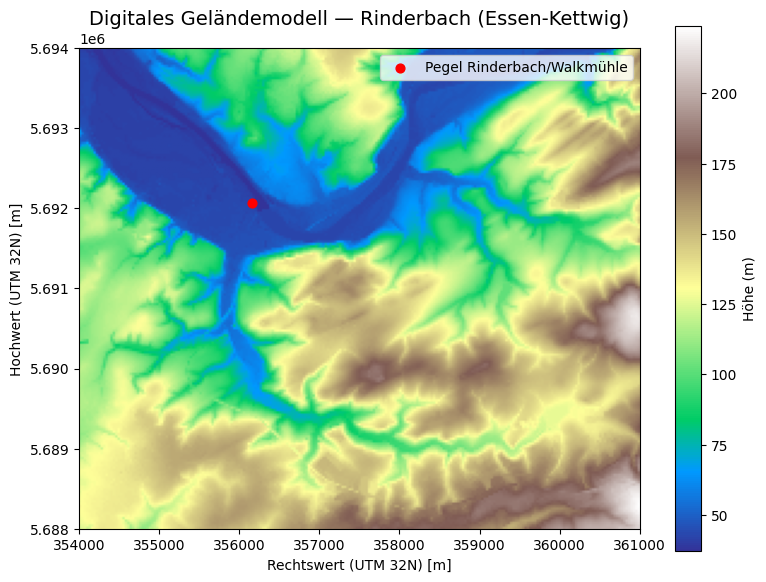

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_alpha(0)

plt.imshow(dem, extent=grid.extent, cmap='terrain', zorder=2)
plt.colorbar(label='Höhe (m)')

plt.scatter(x=[pegel_x], y=[pegel_y], zorder=3, c='red', s=40,
            label='Pegel Rinderbach/Walkmühle')

plt.grid(zorder=0)
plt.title('Digitales Geländemodell — Rinderbach (Essen-Kettwig)', size=14)
plt.xlabel('Rechtswert (UTM 32N) [m]')
plt.ylabel('Hochwert (UTM 32N) [m]')
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# Aufbereitung DGM
# 1) Pits (1-Zellen-Senken) auffüllen
pit_filled_dem = grid.fill_pits(dem)
# 2) Größere Mulden auffüllen
flooded_dem = grid.fill_depressions(pit_filled_dem)
# 3) Flache Bereiche auflösen (kontinuierliche Abwärtsströmung)
inflated_dem = grid.resolve_flats(flooded_dem)

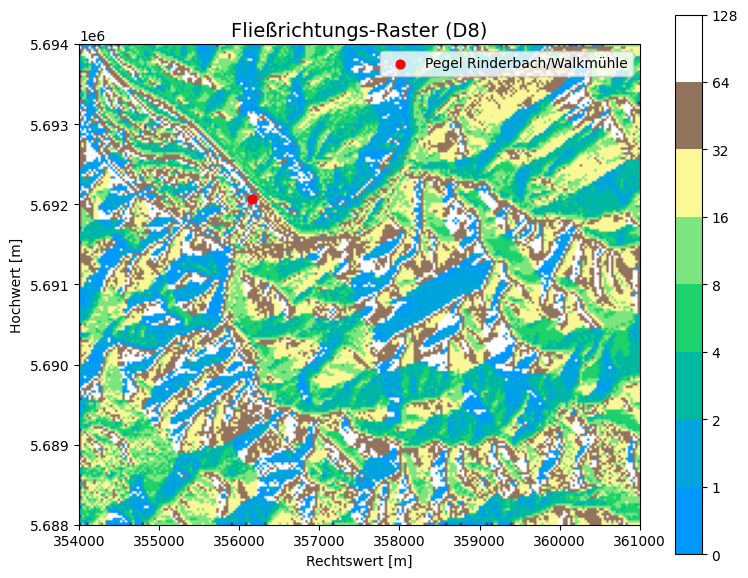

In [23]:
# D8-Richtungs-Mapping
#         N   NE   E  SE  S  SW   W  NW
dirmap = (64, 128, 1,  2, 4,  8, 16, 32)

# Fließrichtungen
fdir = grid.flowdir(inflated_dem, dirmap=dirmap)

fig = plt.figure(figsize=(8, 6))
fig.patch.set_alpha(0)

cNorm = colors.PowerNorm(gamma=0.5)
plt.imshow(fdir, extent=grid.extent, norm=cNorm, cmap='terrain', zorder=2)
boundaries = [0] + sorted(list(dirmap))
plt.colorbar(boundaries=boundaries, values=sorted(dirmap))
plt.scatter(x=[pegel_x], y=[pegel_y], zorder=3, c='red', s=40,
            label='Pegel Rinderbach/Walkmühle')
plt.xlabel('Rechtswert [m]')
plt.ylabel('Hochwert [m]')
plt.title('Fließrichtungs-Raster (D8)', size=14)
plt.legend()
plt.grid(zorder=-1)
plt.tight_layout()
plt.show()

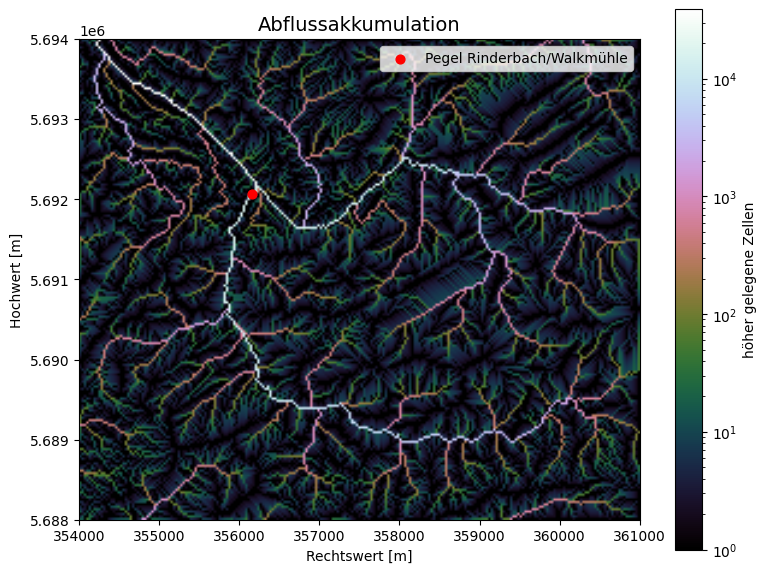

In [24]:
acc = grid.accumulation(fdir, dirmap=dirmap)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_alpha(0)
plt.grid('on', zorder=0)
im = ax.imshow(acc, extent=grid.extent, zorder=2, cmap='cubehelix',
               norm=colors.LogNorm(1, acc.max()), interpolation='bilinear')
plt.scatter(x=[pegel_x], y=[pegel_y], zorder=3, c='red', s=40,
            label='Pegel Rinderbach/Walkmühle')
plt.colorbar(im, ax=ax, label='höher gelegene Zellen')
plt.title('Abflussakkumulation', size=14)
plt.xlabel('Rechtswert [m]')
plt.ylabel('Hochwert [m]')
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# Schwellenwert für die Abflussakkumulation in Zellen.
# Bei 30 m × 30 m-Zellen entsprechen 500 Zellen ≈ 0.45 km².
accumulation_threshold = 500

# Pour Point auf hochakkumulierte Zelle snappen
x_snap, y_snap = grid.snap_to_mask(acc > 1000, (pegel_x, pegel_y))
print(f'Gesnapte Koordinaten: ({x_snap:.1f}, {y_snap:.1f})')

# Einzugsgebiet abgrenzen
catch = grid.catchment(x=x_snap, y=y_snap, fdir=fdir, dirmap=dirmap,
                       xytype='coordinate')

# Auf das Einzugsgebiet zuschneiden
grid.clip_to(catch)
clipped_catch = grid.view(catch)

Gesnapte Koordinaten: (356133.0, 5692080.0)


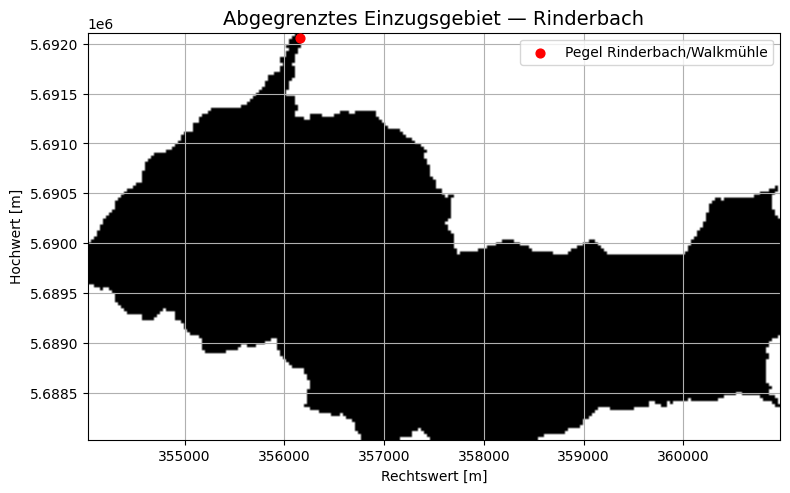

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_alpha(0)
plt.grid('on', zorder=0)
ax.imshow(np.where(clipped_catch, clipped_catch, np.nan),
          extent=grid.extent, zorder=1, cmap='Greys_r')
plt.scatter(x=[pegel_x], y=[pegel_y], zorder=3, c='red', s=40,
            label='Pegel Rinderbach/Walkmühle')
plt.xlabel('Rechtswert [m]')
plt.ylabel('Hochwert [m]')
plt.title('Abgegrenztes Einzugsgebiet — Rinderbach', size=14)
plt.legend()
plt.tight_layout()
plt.show()

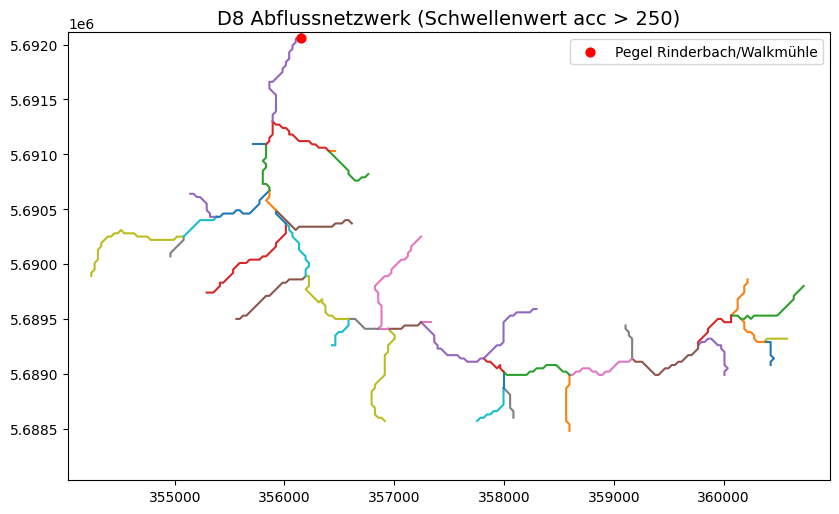

In [27]:
# Flussnetzwerk extrahieren
branches = grid.extract_river_network(fdir, acc > 250, dirmap=dirmap)

fig, ax = plt.subplots(figsize=(8.5, 6.5))
plt.xlim(grid.bbox[0], grid.bbox[2])
plt.ylim(grid.bbox[1], grid.bbox[3])
ax.set_aspect('equal')
for branch in branches['features']:
    line = np.asarray(branch['geometry']['coordinates'])
    plt.plot(line[:, 0], line[:, 1])
plt.scatter(x=[pegel_x], y=[pegel_y], zorder=3, c='red', s=40,
            label='Pegel Rinderbach/Walkmühle')
plt.title('D8 Abflussnetzwerk (Schwellenwert acc > 250)', size=14)
plt.legend()
plt.tight_layout()
plt.show()

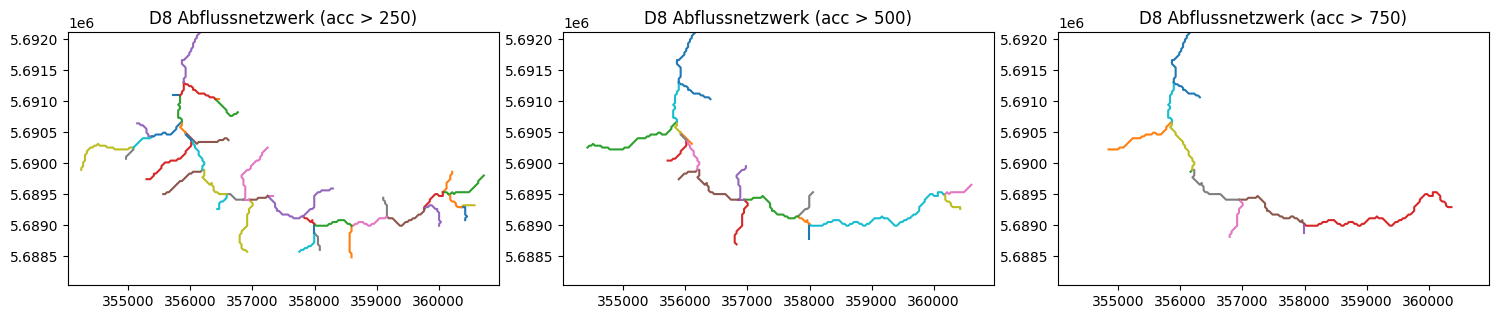

In [28]:
# Sensitivität: Flussnetzwerk für drei verschiedene Akkumulations-Schwellenwerte
acc_levels = [250, 500, 750]
fig, axs = plt.subplots(1, len(acc_levels), figsize=(15, 5))

for i, lvl in enumerate(acc_levels):
    branches_i = grid.extract_river_network(fdir, acc > lvl, dirmap=dirmap)
    axs[i].set_xlim(grid.bbox[0], grid.bbox[2])
    axs[i].set_ylim(grid.bbox[1], grid.bbox[3])
    axs[i].set_aspect('equal')
    for branch in branches_i['features']:
        line = np.asarray(branch['geometry']['coordinates'])
        axs[i].plot(line[:, 0], line[:, 1])
    axs[i].set_title(f'D8 Abflussnetzwerk (acc > {lvl})')

plt.tight_layout()
plt.show()

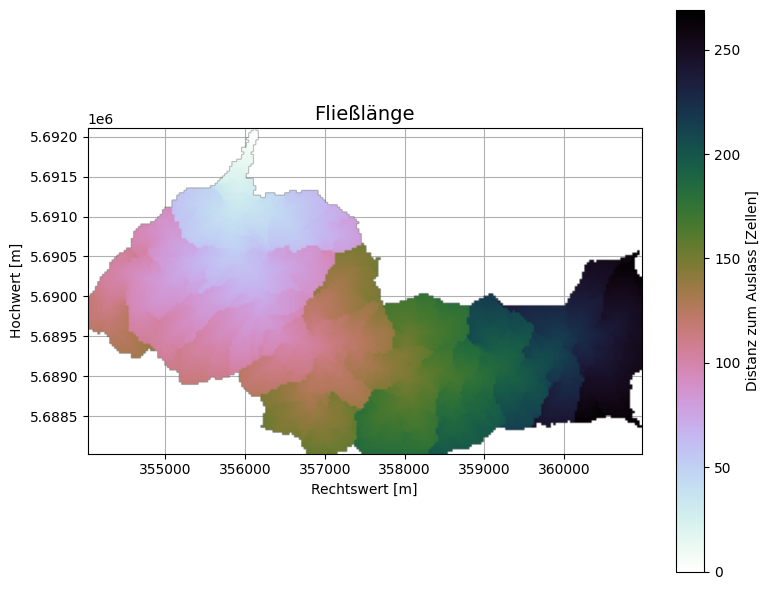

In [29]:
# Entfernung jeder Zelle zum Auslass (in Zellen)
dist = grid.distance_to_outlet(x=x_snap, y=y_snap, fdir=fdir, dirmap=dirmap,
                               xytype='coordinate')

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_alpha(0)
plt.grid('on', zorder=0)
im = ax.imshow(dist, extent=grid.extent, zorder=2, cmap='cubehelix_r')
plt.colorbar(im, ax=ax, label='Distanz zum Auslass [Zellen]')
plt.xlabel('Rechtswert [m]')
plt.ylabel('Hochwert [m]')
plt.title('Fließlänge', size=14)
plt.tight_layout()
plt.show()

In [30]:
# Annahme: in Gerinnezellen fließt Wasser ~10× schneller als in Hangzellen.
# Daher Hangzellen Gewicht 1, Gerinnezellen Gewicht 0.1
acc = grid.accumulation(fdir)
weights = acc.copy()
weights[acc >= accumulation_threshold] = 0.1
weights[(acc > 0) & (acc < accumulation_threshold)] = 1

# Gewichtete Entfernung zum Auslass
weighted_dist = grid.distance_to_outlet(x=x_snap, y=y_snap, fdir=fdir,
                                        weights=weights, xytype='coordinate')

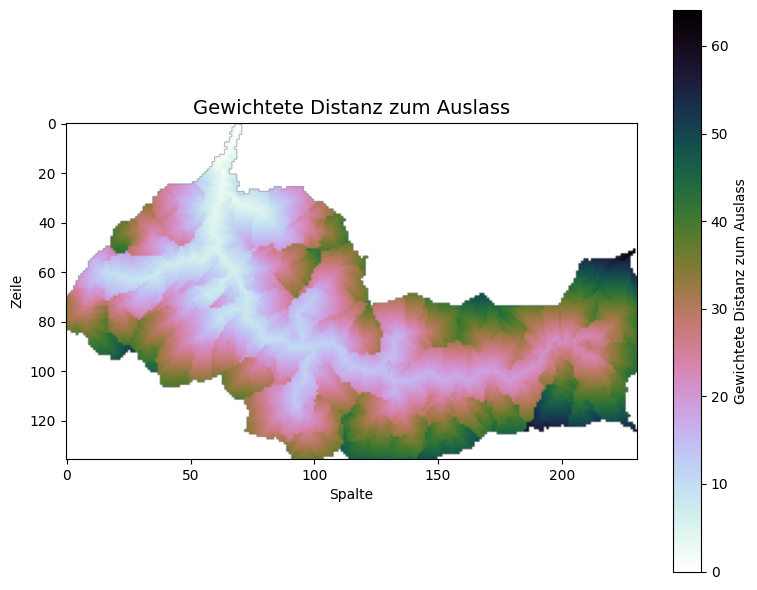

In [31]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_alpha(0)
im = ax.imshow(weighted_dist, zorder=2, cmap='cubehelix_r')
plt.colorbar(im, ax=ax, label='Gewichtete Distanz zum Auslass')
plt.title('Gewichtete Distanz zum Auslass', size=14)
plt.xlabel('Spalte')
plt.ylabel('Zeile')
plt.tight_layout()
plt.show()

In [32]:
# Rasterauflösung (m × m)
resolution = (30, 30)

# Zellen nach gewichtetem Abstand zum Auslass gruppieren
dist_df = pd.DataFrame()
dist_df['weighted_dist'] = weighted_dist.flatten()
print('Vor der Aufbereitung:', dist_df.shape)

# Zellen außerhalb des Einzugsgebiets (NaN/inf) entfernen, ganzzahlig runden
dist_df = dist_df[np.isfinite(dist_df['weighted_dist'])].round(0)
print('Nach der Aufbereitung:', dist_df.shape)
dist_df.head()

Vor der Aufbereitung: (31416, 1)
Nach der Aufbereitung: (16037, 1)


,weighted_dist
69,1.0
299,2.0
300,1.0
301,0.0
529,3.0


In [33]:
# Anzahl Zellen pro Distanz-Bin
grouped_dists = pd.DataFrame(dist_df.groupby('weighted_dist').size())
grouped_dists.columns = ['num_cells']
grouped_dists.head()

,num_cells
weighted_dist,
0.0,6
1.0,19
2.0,37
3.0,44
4.0,74


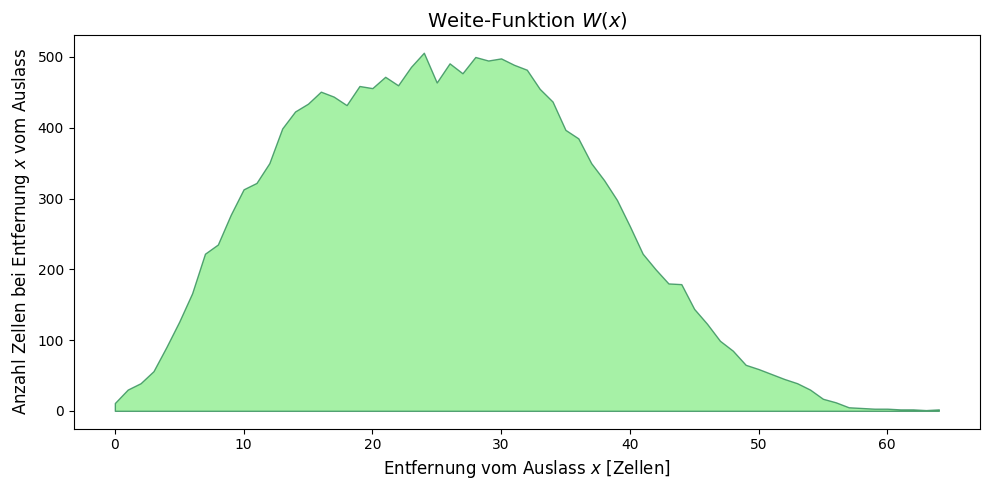

In [34]:
# Verteilung der gewichteten Distanzen plotten (Width-Funktion W(x))
W = np.bincount(weighted_dist[np.isfinite(weighted_dist)].astype(int))
fig, ax = plt.subplots(figsize=(10, 5))
plt.fill_between(np.arange(len(W)), W, 0, edgecolor='seagreen',
                 linewidth=1, facecolor='lightgreen', alpha=0.8)
plt.ylabel(r'Anzahl Zellen bei Entfernung $x$ vom Auslass', size=12)
plt.xlabel(r'Entfernung vom Auslass $x$ [Zellen]', size=12)
plt.title('Weite-Funktion $W(x)$', size=14)
plt.tight_layout()
plt.show()

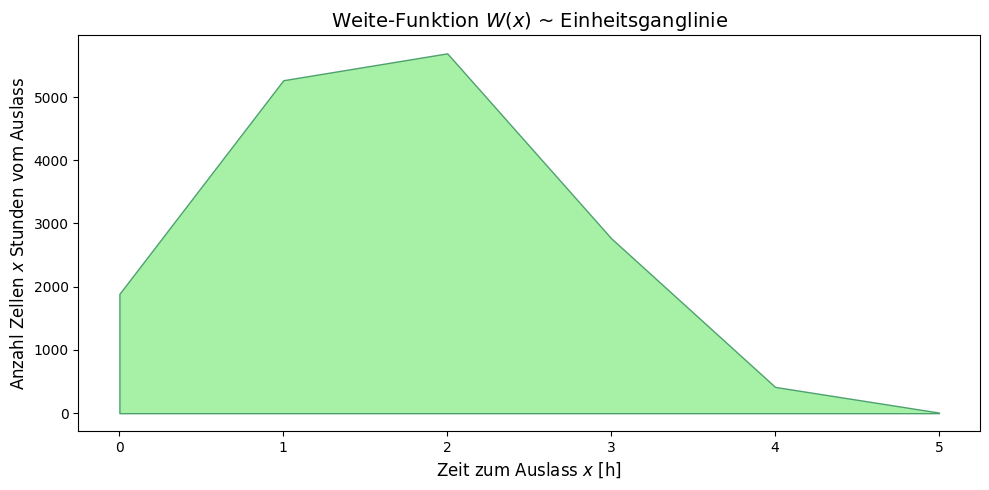

In [35]:
flow_velocity = 0.1  # m/s   (Referenz-Hanggeschwindigkeit)

# Distanz [Zellen] -> Zeit [Stunden]
w_time = weighted_dist * resolution[0] / flow_velocity / 3600
W_time = np.bincount(w_time[np.isfinite(w_time)].astype(int))

fig, ax = plt.subplots(figsize=(10, 5))
plt.fill_between(np.arange(len(W_time)), W_time, 0, edgecolor='seagreen',
                 linewidth=1, facecolor='lightgreen', alpha=0.8)
plt.ylabel(r'Anzahl Zellen $x$ Stunden vom Auslass', size=12)
plt.xlabel(r'Zeit zum Auslass $x$ [h]', size=12)
plt.title('Weite-Funktion $W(x)$ ~ Einheitsganglinie', size=14)
plt.tight_layout()
plt.show()

In [36]:
# Stündliche Daten erneut einlesen (sicherheitshalber, da `hourly_df` u.U. modifiziert)
hourly_df = pd.read_csv(
    data_path + 'hourly_1303.csv',
    sep=';', decimal=',', parse_dates=['date'], index_col='date',
)
if hourly_df.index.tz is not None:
    hourly_df.index = hourly_df.index.tz_localize(None)

# Auf den Tag des betrachteten Ereignisses kürzen
event_start = '2024-02-26'
event_end   = '2024-02-26'
hourly_df = hourly_df.loc[event_start:event_end].copy()

hourly_source = ColumnDataSource(hourly_df)
print(f'Ereignisfenster: {hourly_df.index.min()} – {hourly_df.index.max()}')
print(f'Stündliche Niederschlagssumme: {hourly_df["value"].sum():.1f} mm')
hourly_df.head()

Ereignisfenster: 2024-02-26 00:00:00 – 2024-02-26 23:00:00
Stündliche Niederschlagssumme: 8.2 mm


,station_id,dataset,parameter,value,quality
date,,,,,
2024-02-26 00:00:00,1303,precipitation,precipitation_height,0.0,1.0
2024-02-26 01:00:00,1303,precipitation,precipitation_height,0.0,1.0
2024-02-26 02:00:00,1303,precipitation,precipitation_height,0.0,1.0
2024-02-26 03:00:00,1303,precipitation,precipitation_height,0.0,1.0
2024-02-26 04:00:00,1303,precipitation,precipitation_height,0.6,1.0


In [37]:
# Erstellung einer leeren Abflusszeitreihe für jede Niederschlagsstunde
runoff_df = pd.DataFrame(np.zeros(len(hourly_df)), columns=['Total Precip (mm)'])
runoff_df.index = hourly_df.index.copy()

end_time = pd.to_datetime(runoff_df.index.values[-1]) + pd.DateOffset(hours=1)
max_distance = max(grouped_dists.index)

In [38]:
def calculate_flow_time(distance, v):
    """Distanz [Zellen] -> volle Stunden Fließzeit (auf nächste Stunde aufgerundet)."""
    return np.ceil(distance * resolution[0] / v / 3600)


# Maximale Fließzeit (Konzentrationszeit) im Einzugsgebiet
max_flow_time = int(calculate_flow_time(max_distance, flow_velocity))
print(f'Maximaler Abflussweg = {max_distance} Zellen, '
      f'maximale Fließzeit = {max_flow_time} Stunden.')

# DataFrame um diese maximale Fließzeit nach hinten verlängern
extended_df = pd.DataFrame({'Total Precip (mm)': [0] * (max_flow_time + 1)},
                           index=pd.date_range(end_time, periods=max_flow_time + 1, freq='h'))

runoff_df = pd.concat([runoff_df, extended_df])
runoff_df['Runoff (cms)'] = 0.0  # explizit float

Maximaler Abflussweg = 64.0 Zellen, maximale Fließzeit = 6 Stunden.


In [39]:
# Sicherstellen: Spalte ist float
runoff_df['Runoff (cms)'] = runoff_df['Runoff (cms)'].astype(float)

runoff_coefficient = 0.71

for ind, row in hourly_df.iterrows():
    for weight_dist, num_cells_row in grouped_dists.iterrows():
        # Fließzeit (auf volle Stunde aufgerundet) für diese Distanz-Gruppe
        weighted_time_hrs = calculate_flow_time(weight_dist, flow_velocity)
        outlet_time = ind + pd.Timedelta(hours=weighted_time_hrs)
        if weighted_time_hrs < 1:
            outlet_time = ind + pd.Timedelta(hours=1)

        num_cells_value = num_cells_row['num_cells']
        precip_vol      = num_cells_value * row['value']           # mm·#cells
        # Volumen in m³: mm/1000 -> m, mal Zellfläche resolution²
        runoff_vol_m3   = precip_vol * runoff_coefficient / 1000 * resolution[0] ** 2
        runoff_rate_cms = runoff_vol_m3 / 3600                     # m³/s gemittelt über 1 h

        if outlet_time in runoff_df.index:
            runoff_df.loc[outlet_time, 'Runoff (cms)'] += runoff_rate_cms

In [40]:
# Tagesvolumen aus dem stündlich modellierten Abfluss
runoff_df['day'] = runoff_df.index.day
runoff_df['runoff_vol_cmh'] = runoff_df['Runoff (cms)'] * 3600
cumulative_vol = runoff_df[['runoff_vol_cmh', 'day']].groupby('day').sum()
cumulative_vol.rename(columns={'runoff_vol_cmh': 'runoff_vol_m3d'}, inplace=True)
cumulative_vol

,runoff_vol_m3d
day,
26,84030.6726
27,0.0000


In [41]:
pegel_path = data_path + 'pegel_rinderbach_BRW.csv'

pegel_df = pd.read_csv(pegel_path, skiprows=13, sep=';', decimal=',',
                       index_col='Tag', parse_dates=True, dayfirst=True)
# Auf das Ereignis kürzen (Tag des Ereignisses + Folgetag)
pegel_df = pegel_df.loc['2024-02-26':'2024-02-27'].round(3)
pegel_df['Tages Mittel'] = pegel_df['Tages Mittel'].astype(float)
pegel_df

,Tages Minimum,Tages Mittel,Tages Maximum,Status
Tag,,,,
2024-02-26,0.373,0.567,1.286,NaN
2024-02-27,0.373,0.413,0.467,NaN


In [42]:
# Vergleich modellierter ↔ gemessener Tagesabfluss
# Hinweis: für ein Mittelgebirgs-EZG wie den Rinderbach ist der Basisabfluss deutlich
# kleiner als der Spitzenabfluss eines Niederschlagsereignisses; wir setzen ihn
# vereinfacht auf 0 (Sensitivitätsanalyse möglich).
pegel_df['excess_flow']   = pegel_df['Tages Mittel']
pegel_df['excess_volume'] = pegel_df['excess_flow'] * 3600 * 24  # m³/Tag

# Modelliertes Tagesvolumen einfügen (nur für die Tage mit modellierten Werten)
modelled_days = cumulative_vol.values.flatten()
target_idx = pegel_df.index[:len(modelled_days)]
pegel_df.loc[target_idx, 'model_volume'] = modelled_days
pegel_df

,Tages Minimum,Tages Mittel,Tages Maximum,Status,excess_flow,excess_volume,model_volume
Tag,,,,,,,
2024-02-26,0.373,0.567,1.286,NaN,0.567,48988.8,84030.6726
2024-02-27,0.373,0.413,0.467,NaN,0.413,35683.2,0.0000


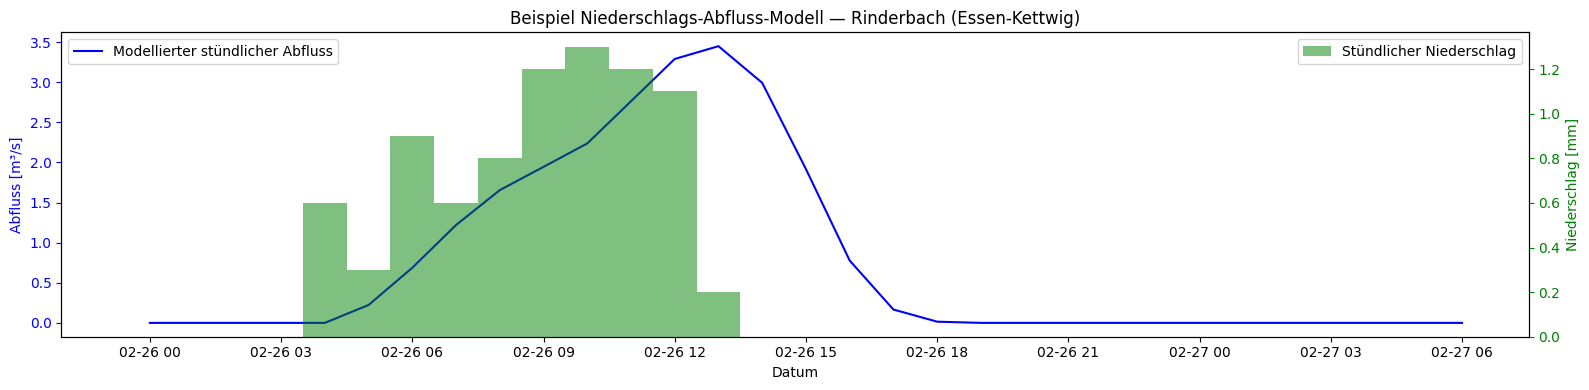

In [43]:
# Plot: modellierter stündlicher Abfluss vs. Niederschlag
fig, ax = plt.subplots(1, 1, figsize=(16, 4))
ax.plot(runoff_df.index, runoff_df['Runoff (cms)'],
        color='blue', label='Modellierter stündlicher Abfluss')
ax.set_xlabel('Datum')
ax.set_ylabel('Abfluss [m³/s]', color='blue')
ax.set_title('Beispiel Niederschlags-Abfluss-Modell — Rinderbach (Essen-Kettwig)')
ax.legend(loc='upper left')
ax.tick_params(axis='y', colors='blue')

ax1 = ax.twinx()
ax1.bar(hourly_df.index, width=pd.Timedelta(hours=1), height=hourly_df['value'],
        color='green', alpha=0.5, label='Stündlicher Niederschlag')
ax1.set_ylabel('Niederschlag [mm]', color='green')
ax1.tick_params(axis='y', colors='green')
ax1.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [44]:
tot_runoff = pegel_df[['excess_volume', 'model_volume']].sum()
relative_error = 100 * (tot_runoff['excess_volume'] - tot_runoff['model_volume']) / tot_runoff['excess_volume']

print(f'Gemessenes Volumen:    {tot_runoff["excess_volume"]:>12,.0f} m³')
print(f'Modelliertes Volumen:  {tot_runoff["model_volume"]:>12,.0f} m³')
print(f'Relativer Fehler:      {relative_error:>12.1f} %')
print()
print(f'Bei einem Abflusskoeffizienten von {runoff_coefficient} '
      f'({100*runoff_coefficient:.0f}% des Niederschlages sind effektiver Niederschlag) '
      f'beträgt der Vorhersagefehler über das Niederschlagsereignis {relative_error:.0f} %.')

Gemessenes Volumen:          84,672 m³
Modelliertes Volumen:        84,031 m³
Relativer Fehler:               0.8 %

Bei einem Abflusskoeffizienten von 0.71 (71% des Niederschlages sind effektiver Niederschlag) beträgt der Vorhersagefehler über das Niederschlagsereignis 1 %.


In [45]:
precip_losses = [1, 2, 4]  # mm/h

p = figure(title='Niederschlag vs. Verluste', width=750, height=300, x_axis_type='datetime')

p.vbar(x='date', width=pd.Timedelta(hours=1), top='value',
       bottom=0, source=hourly_source,
       legend_label='Stündlicher Niederschlag',
       color='royalblue', fill_alpha=0.5)

t_loss = [hourly_df.index[0], hourly_df.index[-1]]
plot_colors = ['blue', 'green', 'orange', 'red']
for i, l in enumerate(precip_losses):
    p.line(t_loss, [l, l], line_dash='dashed',
           legend_label=f'{l} mm/h Verlust', color=plot_colors[i])

p.legend.location = 'top_left'
p.xaxis.axis_label = 'Datum'
p.yaxis.axis_label = 'Niederschlag [mm]'
p.toolbar_location = 'above'
show(p)

In [46]:
for l in precip_losses:
    hourly_df[f'excess_{l}'] = (hourly_df['value'] - l).clip(lower=0)

hourly_df['day'] = hourly_df.index.day

excess_rainfall = (hourly_df[[f'excess_{l}' for l in precip_losses] + ['day']]
                   .groupby('day').sum())
excess_rainfall

,excess_1,excess_2,excess_4
day,,,
26,0.8,0.0,0.0


In [47]:
# Bokeh-Plot: effektiver Niederschlag je Verlustrate (versetzt für Lesbarkeit)
hourly_source = ColumnDataSource(hourly_df)
p = figure(title='Effektiver Niederschlag', width=650, height=250, x_axis_type='datetime')

for i, l in enumerate(precip_losses):
    p.vbar(x='date', width=pd.Timedelta(minutes=20), top=f'excess_{l}',
           bottom=0, source=hourly_source,
           legend_label=f'{l} mm Verlust', color=plot_colors[i], fill_alpha=0.5)
    # Visueller Trick: Index um 20 min verschieben, damit Balken nebeneinander liegen
    hourly_df.index += pd.Timedelta(minutes=20)
    hourly_source = ColumnDataSource(hourly_df)

# Index zurücksetzen (3 × 20 min = 1 h)
hourly_df.index -= pd.Timedelta(hours=1)
p.legend.location = 'top_left'
show(p)

In [48]:
# Welcher Anteil des Niederschlags wird bei welcher Verlustrate effektiv?
total_hourly_vol = hourly_df.groupby('day').sum()[['value'] + [f'excess_{l}' for l in precip_losses]]
tot_df = total_hourly_vol.sum()

for ev in precip_losses:
    e_pct = tot_df[f'excess_{ev}'] / tot_df['value']
    tot_df[f'pct_excess_{ev}'] = e_pct
    print(f'{ev} mm/h Verlust  ->  {100*e_pct:5.1f} % des Niederschlags wird Direktabfluss')

1 mm/h Verlust  ->    9.8 % des Niederschlags wird Direktabfluss
2 mm/h Verlust  ->    0.0 % des Niederschlags wird Direktabfluss
4 mm/h Verlust  ->    0.0 % des Niederschlags wird Direktabfluss
